# Fake News Detection (Manual ML Pipeline)
This notebook demonstrates a manual machine learning pipeline to classify news as Fake or Real without using AutoML. We use TF-IDF vectorization and traditional classifiers such as Logistic Regression and Naive Bayes.

## Introduction
Fake news detection is a fundamental challenge in modern information systems. In this notebook, we use a dataset of real and fake news articles to train traditional machine learning models for binary classification.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

## Load and Prepare Data

In [5]:
true = pd.read_csv('True.csv')
fake = pd.read_csv('Fake.csv')

true['label'] = 1
fake['label'] = 0

df = pd.concat([true, fake], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df = df.drop(columns=['subject', 'date', 'author'], errors='ignore')
df.dropna(inplace=True)
df['text_combined'] = df['title'] + ' ' + df['text']
df = df[['text_combined', 'label']]
df.columns = ['text', 'label']

## Exploratory Data Analysis (EDA)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    44898 non-null  object
 1   label   44898 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 701.7+ KB


In [8]:
df.head()

,text,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,0
1,Failed GOP Candidates Remembered In Hilarious...,0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,0
3,California AG pledges to defend birth control ...,1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,0


In [9]:
df['label'].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64

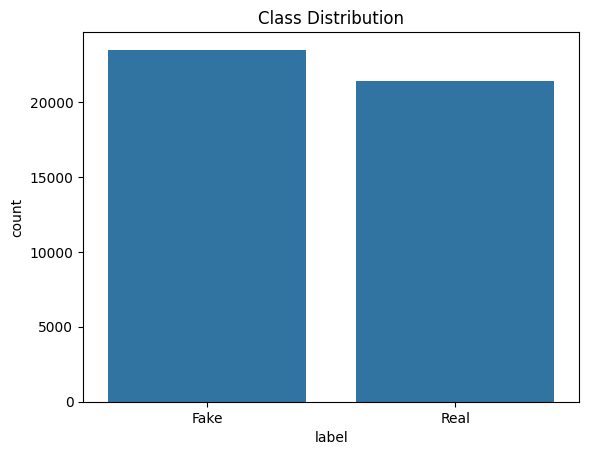

In [10]:
sns.countplot(x='label', data=df)
plt.xticks([0, 1], ['Fake', 'Real'])
plt.title('Class Distribution')
plt.show()

In [11]:
df['text_length'] = df['text'].apply(lambda x: len(x.split()))
df['text_length'].describe()

count    44898.000000
mean       417.735757
std        351.480777
min          2.000000
25%        216.000000
50%        375.000000
75%        526.000000
max       8148.000000
Name: text_length, dtype: float64

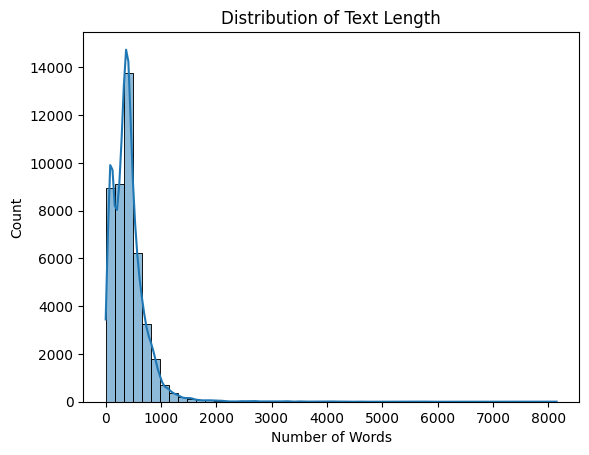

In [12]:
sns.histplot(df['text_length'], bins=50, kde=True)
plt.title('Distribution of Text Length')
plt.xlabel('Number of Words')
plt.show()

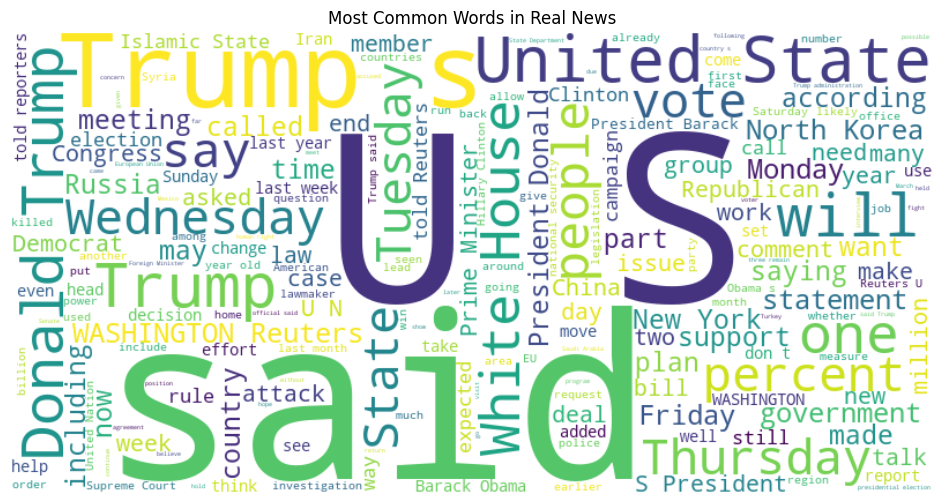

In [13]:
from wordcloud import WordCloud
text_all = ' '.join(df[df['label'] == 1]['text'])  # Real News
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_all)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Real News')
plt.show()

## Train/Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.2, random_state=42)

## TF-IDF Vectorization

In [17]:
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

## Model 1: Logistic Regression

In [19]:
lr = LogisticRegression()
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)
print("Logistic Regression Results:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4669
           1       0.98      0.99      0.99      4311

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



## Model 2: Multinomial Naive Bayes

In [21]:
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)
print("Naive Bayes Results:\n")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Results:

              precision    recall  f1-score   support

           0       0.93      0.94      0.94      4669
           1       0.94      0.92      0.93      4311

    accuracy                           0.93      8980
   macro avg       0.93      0.93      0.93      8980
weighted avg       0.93      0.93      0.93      8980



## Save Best Model (Logistic Regression shown here)

In [23]:
joblib.dump(lr, 'fake_news_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

## Conclusion
We manually built and evaluated two models for fake news detection using TF-IDF vectorization and traditional classifiers. Logistic Regression and Naive Bayes both showed solid performance, and the trained model is saved for deployment.